# <center><h2><b> <span style="color:blue">КУРСОВАЯ РАБОТА АССН</span></h2></b>    

## <span style="color:blue">Построение траектории движения воздушного объекта на первом прямолинейом участке</span>   

Для построения траектории движения воздушного объекта в нормальной земной системе координат необходимо осуществить переход от одной системы координат ко второй системе координат по следующим формулам
$$
K_1 = M^{-1} ∙ K_2
$$
Где М - транспонированная матрица пересчета
$$
M^{-1} = 
\begin {cases}
\cos(u) \text{  }-\sin(u)\\
\sin(u) \text{  } \cos(u)\\
\end {cases}
$$

In [9]:
# введите точки пересечения справа на лево
point_round = [188, 26] # эти значения приодятся дальше при выполнении курсовой работы



#пересчет координат
from numpy import sin, cos, radians
#Ввод пользовательских данных
#"Введите X координату"
x0 = float(-450)
#"Введите Y координату"
y0 = float(217)
#-----------------------------
x2 = int(x0*cos(radians(90)) + y0*sin(radians(90)))*1000
y2 = int(x0*sin(radians(90)) + y0*cos(radians(90)))*1000
print("Новый X: " + str(x2/1000))
print("Новый Y: " + str(y2/1000))

Новый X: 216.0
Новый Y: -450.0


Модель движения воздушного объекта на участках равномерного и прямолинейного движения в прямоугольной системе координат на каждом шаге описывается выражениями:
$$
x_i=x_{i-1}+v_i∙\sin(u)∙T
$$
$$
y_i=y_{i-1}+v_i∙\cos(u)∙T
$$

$$
x_i, y_i - \text{координаты воздушного объекта на i-том измерении}\\
v_i - \text{случайное значение скорости полёта воздушного объекта из смоделированного массива значений}\\
T - \text{период моделирования}\\
u - \text{курс движения ВО}\\
$$

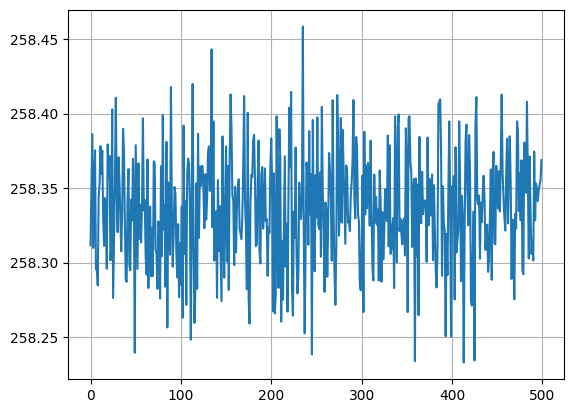

In [10]:
import random
import matplotlib.pyplot as plt
from numpy import sqrt, random
#Исходные данные
V = 930   /3.6 # скорость полёта ВО м/с
ra=0.04
T = 1 # период моделирования

#вычисление параметров
yS = random.normal(loc=V, scale=ra, size=500)
xS = [i for i in range(0, 500)]
plt.plot(xS, yS, label="Скорость ВО в течении полета")
plt.grid()
plt.show()

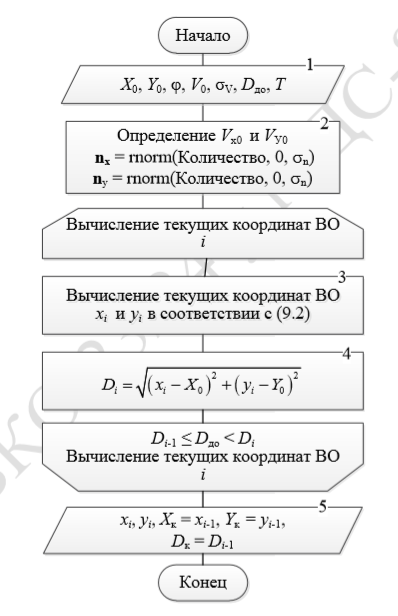

In [11]:
from numpy import radians, cos, sin, sqrt
#первоначальный угл полета
ugls = 334
uglsr = radians(ugls)
#дальность до маневра в метрах
S_max = 491000 
s_max = 0

#точка стояния РЛС
x_point = 0
y_point = 0
y_rounds = []
x_rounds = []
#начальная точка полета ВО на 1 прямолинейном участке движения
x_line = [x2]
y_line = [y2]
#построние сечения зоны обнаружения РЛС
for p in range(0, 360):
    x_rounds.append(point_round[0]*1000*sin(radians(p)))
    y_rounds.append(point_round[0]*1000*cos(radians(p))) 
plt.plot(y_rounds, x_rounds, color='red', linestyle='--')

#построение трактории движения ВО до маневра
D=0.0
i=0
while(D<S_max):
    new_x=x_line[i]+V*sin(uglsr)*T
    new_y=y_line[i]+V*cos(uglsr)*T
    D += sqrt((x_line[i]-new_x)*(x_line[i]-new_x)+(y_line[i]-new_y)*(y_line[i]-new_y))
    if D<S_max:
        x_line.append(new_x)
        y_line.append(new_y)
        i+=1
D-=sqrt((x_line[i]-new_x)*(x_line[i]-new_x)+(y_line[i]-new_y)*(y_line[i]-new_y))
print(" факт.пролетел:" + str(D))
print(" х конечный:" + str(x_line[len(x_line)-1]))
print(" y_конечный:" + str(y_line[len(y_line)-1]))
plt.axis('equal')
plt.plot(x_line, y_line, color='green', label="Тректория движения ВО") 
plt.grid()
plt.show()

NameError: name 'point_round' is not defined

# Задание №2
[Назад в СОДЕРЖАНИЕ](#Содержание)

## <span style="color:blue">Построение траектории движения воздушного объекта на участке его маневрирования</span>   

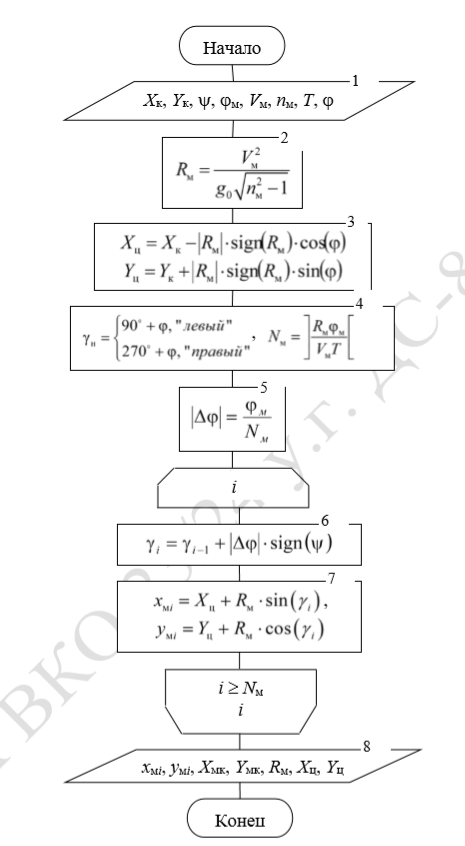

 радиус виража:7766.044762377099
 х конечный:209019.92520428263
 y конечный:-453404.40994849853
---
приращение угла-1.8936170212765957
кол-во точек маневра-1
кол-во точек маневра-93


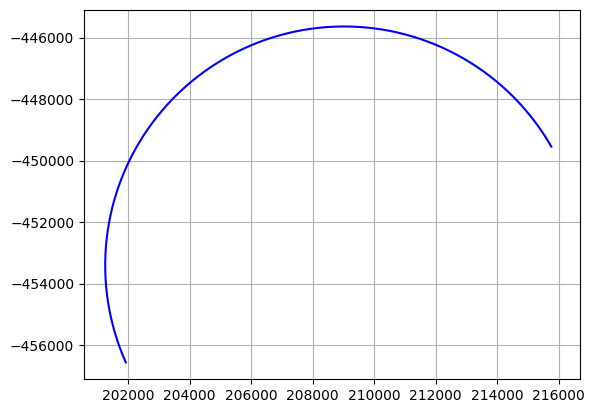

In [12]:

from numpy import degrees
#данные
g0 = 9.8 #ускорение свободного падения
n_m = 1.33 #нормальная перегрузка на вираже
V_manevr = V #скорость на вираже
right = False # направление маневра если правый то True, левый - False
fi_m = radians(178) # Угла разворота

#радиус виража
R_m = (V_manevr*V_manevr)/(g0*sqrt(n_m**2 -1))
print(" радиус виража:" + str(R_m))

#направление маневра
if right:
    signR = -1
else:
    signR = 1
    
#Координаты центра виража
X_center = x_line[len(x_line)-1]-abs(R_m)*signR*cos(uglsr)
Y_center = y_line[len(y_line)-1]+abs(R_m)*signR*sin(uglsr)
print(" х конечный:" + str(X_center))
print(" y конечный:" + str(Y_center))
print("---")

#направление маневра
if right:
    signY = 1
else:
    signY = -1
    
#начальный угл движения
if right:
    Ystart = 270+ugls
else:
    Ystart = 90+ugls
Ystart_r = radians(Ystart)


#Количество точек моделировования
N_point = int((R_m*fi_m)/(V_manevr*T)+1)

#дискрета приращения угла на каждом шаге моделирования
dY = abs((fi_m)/(N_point))
print("приращение угла-" + str(degrees(dY)))

#моделировование маневра
x_manewr = []
y_manewr = []
y_cur = []
y_cur.append(Ystart + degrees(dY)*signY) #расчеты в градусах
for i in range(0, N_point-1):
    #угл изменения виража на каждом шаге
    y_cur.append(y_cur[len(y_cur)-1] + degrees(dY)*signY) #расчеты в градусах
    #координаты на каждом участке моделировования
    x_manewr.append(X_center + R_m*sin(radians(y_cur[len(y_cur)-1])))
    y_manewr.append(Y_center + R_m*cos(radians(y_cur[len(y_cur)-1])))   
print("кол-во точек маневра-" + str(len(x_line)))
print("кол-во точек маневра-" + str(len(x_manewr)))

#построение траекторий
plt.axis('equal')
plt.plot(x_line, y_line, color='green', label="Тректория движения ВО") 
plt.plot(x_manewr, y_manewr, color='blue', label="Тректория маневра ВО") 
plt.plot(y_rounds, x_rounds, color='red', linestyle='--', label="зона обнаружения РЛС")
plt.grid()
plt.show()

# Задание №3
[Назад в СОДЕРЖАНИЕ](#Содержание)

## <span style="color:blue">Построение траектории движения воздушного объекта на втором прямолинейном участке движения</span>  

 угл полета на 2 участке -114.00000000000131
 факт.пролетел:248775.00000003484
 х конечный:303111.1986689538
 х конечный:-683830.4161501942


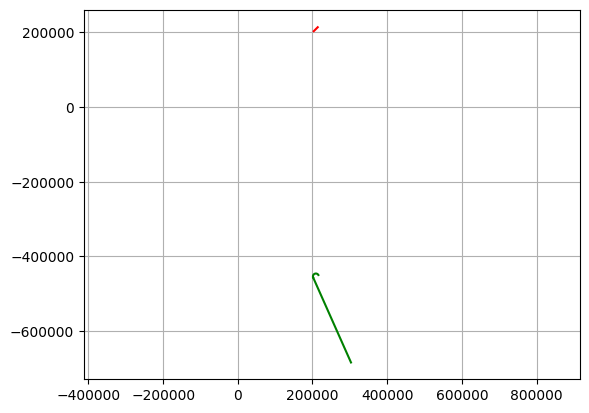

In [16]:
from numpy import radians, cos, sin, sqrt
#дальность после маневра в метрах
S_max2 = 249000 # м
s_max2 = 0
x_line2 = [x_manewr[len(x_manewr)-1]]
y_line2 = [y_manewr[len(y_manewr)-1]]
print(" угл полета на 2 участке " + str(y_cur[len(y_cur)-1]-360))
#Угол полета

if right:
    ugls2 = ugls+degrees(fi_m)
else:
    ugls2 = ugls-degrees(fi_m)
uglsr2 = radians(ugls2)
#построение трактории движения ВО до маневра
D=0.0
i=0
while(D<S_max2):
    #вычисление скорости в каждый момент времени с учетом теории вероятности
    new_x=x_line2[i]+V*sin(uglsr2)*T
    new_y=y_line2[i]+V*cos(uglsr2)*T
    D += sqrt((x_line2[i]-new_x)*(x_line2[i]-new_x)+(y_line2[i]-new_y)*(y_line2[i]-new_y))
    if D<S_max2:
        x_line2.append(new_x)
        y_line2.append(new_y)
        i+=1
D-=sqrt((x_line2[i]-new_x)*(x_line2[i]-new_x)+(y_line2[i]-new_y)*(y_line2[i]-new_y))
print(" факт.пролетел:" + str(D))
print(" х конечный:" + str(x_line2[len(x_line2)-1]))
print(" х конечный:" + str(y_line2[len(y_line2)-1]))
#построение траекторий
plt.axis('equal')
plt.plot(x_line, y_line, color='green', label="Первая ректория движения ВО") 
plt.plot(x_manewr, y_manewr, color='green', label="Тректория маневра ВО") 
plt.plot(x_line2, y_line2, color='green', label="Вторая тректория движения ВО") 
plt.plot(y_rounds, x_rounds, color='red', linestyle='--', label="зона обнаружения РЛС")
plt.grid()
plt.show()

### Сохранение данных, необходимых для второй главы

In [14]:
x_write = x_line + x_manewr + x_line2
y_write = y_line + y_manewr + y_line2
with open("data_G1.txt", "w") as file:
    file.write("x_coord = [")
    file.write(', '.join(map(str, x_write)))
    file.write(']\n')
    file.write("y_coord = [")
    file.write(', '.join(map(str, x_write)))
    file.write(']\n')
    file.write("x_rounds = [")
    file.write(', '.join(map(str, x_write)))
    file.write(']\n')
    file.write("y_rounds = [")
    file.write(', '.join(map(str, x_write)))
    file.write(']')

Загрузка данных из сохраненного файла

In [15]:
run "data_G1.txt"